# Notebook 4: Support Vector Machine & Model Comparison

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Multiclass classification — predict kidney cell type from gene expression

---

## What this notebook does
1. Load the preprocessed train/test sets
2. Train a baseline SVM classifier
3. Tune hyperparameters using Bayesian Optimisation (BayesSearchCV)
4. Evaluate — classification report, confusion matrix, ROC curves
5. Per-class performance analysis
6. Compare KNN vs SVM side by side

## 1. Mount Google Drive

This notebook reads the same four files as Notebook 3 from the folder set as `data_dir`. Locally that is the repo folder; on Colab, mount Drive and set `data_dir`.

In [1]:
# Reads the files written by Notebook 2 from the folder set as data_dir below.
# On Colab instead, uncomment to mount Drive:
# from google.colab import drive
# drive.mount('/content/drive')
print('Setup: reading data from the folder set as data_dir below.')

Setup: reading data from the folder set as data_dir below.


## 2. Configuration

Import the libraries (scikit-learn SVM, scikit-optimize for Bayesian search, imbalanced-learn for balancing) and set the data folder, random seed, and per-class balancing cap `CAP`. `make_resamplers()` builds the SMOTE + undersampling steps used inside the CV pipeline.

In [2]:
!pip install scikit-optimize -q

from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.model_selection  import StratifiedKFold
from skopt                    import BayesSearchCV
from skopt.space              import Real
from sklearn.preprocessing    import label_binarize
from sklearn.metrics          import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, precision_score, recall_score
)
from imblearn.over_sampling   import SMOTE
from imblearn.under_sampling  import RandomUnderSampler
from imblearn.pipeline        import Pipeline as ImbPipeline

data_dir    = Path('.')
random_seed = 42
CAP         = 1000

def make_resamplers():
    # Undersample majority class(es) to CAP, then SMOTE the rest up to CAP.
    # imblearn steps so balancing happens INSIDE each CV fold (no leakage).
    under = RandomUnderSampler(
        sampling_strategy=lambda y: {c: CAP for c, v in Counter(y).items() if v > CAP},
        random_state=random_seed)
    over = SMOTE(
        sampling_strategy=lambda y: {c: CAP for c, v in Counter(y).items() if v < CAP},
        random_state=random_seed, k_neighbors=5)
    return [('under', under), ('over', over)]

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## Note on Compute

This notebook runs on CPU with scikit-learn. RBF-SVM training cost grows quickly with the number of rows, so the training set is balanced to a fixed per-class cap (`CAP`) via SMOTE + undersampling **inside** the CV pipeline, which keeps each fit affordable. Balancing is re-fit per fold, so the test set is never resampled and the cross-validated score stays honest.

## 3. Load Data

Load the same four files used in Notebook 3. Both models are evaluated on exactly the same training and test data so the comparison in Section 11 is fair. `X_train` contains the raw 7,996-cell stratified training split (SMOTE was not applied in this run). `X_test` and `y_test` are the original 1,999 held-out cells with the real class distribution. `classes` is built the same way — sorted unique labels from `y_train` — ensuring consistent ordering across all outputs.

In [3]:
X_train = pd.read_csv(data_dir / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col=0)
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col=0).squeeze()

classes = sorted(y_train.unique())

print(f'Training set : {X_train.shape[0]:,} cells x {X_train.shape[1]:,} genes')
print(f'Test set     : {X_test.shape[0]:,} cells x {X_test.shape[1]:,} genes')
print(f'Classes      : {len(classes)}')

Training set : 16,000 cells x 293 genes
Test set     : 4,000 cells x 293 genes
Classes      : 10


## 4. How SVM Works

A Support Vector Machine finds the decision boundary (hyperplane) that maximises the margin between classes. It focuses on the training cells closest to the boundary — these are the support vectors.

For multiclass problems, sklearn's SVC uses a one-vs-one (OvO) strategy by default: it trains one binary classifier for every pair of classes, then combines their votes to predict the final class.

**`class_weight='balanced'`:** The dataset is imbalanced — Proximal Tubule cells make up over a third of all cells. With balanced class weights, the SVM assigns higher penalty to misclassifying minority classes, preventing the model from ignoring them.

**`probability=True`:** This enables `predict_proba()`, which is needed for ROC curve computation. It uses Platt scaling internally, which adds a small amount of extra training time.

**`kernel` parameter:**
- `'rbf'` (Radial Basis Function) — maps data into a higher-dimensional space to find non-linear boundaries. Generally the strongest kernel for complex data.
- `'linear'` — finds a linear boundary. Faster on high-dimensional data (like gene expression) and tends to work well when there are many informative features.

## 5. Baseline SVM

We train a baseline SVM with an RBF kernel using scikit-learn's `SVC`, wrapped in a pipeline that balances the training folds first. `probability=True` enables `predict_proba`, which we need for the ROC curves.

In [4]:
# Baseline SVM (RBF). SMOTE + undersampling balance the training data first;
# probability=True enables predict_proba for ROC curves (via Platt scaling).
baseline_svm = ImbPipeline(make_resamplers() + [
    ('svc', SVC(kernel='rbf', probability=True, random_state=random_seed, cache_size=800))])
baseline_svm.fit(X_train, y_train)
y_pred_base = baseline_svm.predict(X_test)
y_prob_base = baseline_svm.predict_proba(X_test)

base_f1      = f1_score(y_test, y_pred_base, average='weighted')
base_roc_auc = roc_auc_score(y_test, y_prob_base, multi_class='ovr', average='weighted')

print('Baseline SVM (RBF kernel)')
print(f'  Weighted F1  : {base_f1:.4f}')
print(f'  Weighted AUC : {base_roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, labels=classes, target_names=classes, zero_division=0))

Baseline SVM (RBF kernel)
  Weighted F1  : 0.7890
  Weighted AUC : 0.9711

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.70      0.75      0.72       247
             Distal Convoluted Tubule       0.31      0.54      0.40       145
                          Endothelium       0.93      0.96      0.94       189
Loop of Henle and Parietal Epithelium       0.23      0.65      0.34       147
                              Myeloid       0.90      0.75      0.82       208
                      Proximal Tubule       0.98      0.80      0.88      1979
                                    T       0.97      0.95      0.96       274
                 Thick Ascending Limb       0.60      0.61      0.61       218

                             accuracy                           0.76      4000
                            macro avg       0.69      0.73      0.69      4000
                         weighted avg       0.83      

**Interpreting the baseline SVM:** The baseline RBF SVM already separates the well-represented cell types strongly. Tuning `C` and `gamma` below refines the decision boundary; the gain over baseline is usually small because the RBF defaults are already reasonable for this data.

## 6. Hyperparameter Tuning — Bayesian Optimisation

In Notebook 3 we used **RandomizedSearchCV**, which samples combinations randomly without any memory of past results. Here we use **Bayesian Optimisation** (`BayesSearchCV` from the `scikit-optimize` library), which is smarter.

Bayesian optimisation works by:
1. Trying a few initial random combinations to gather early information
2. Building a probabilistic model (a surrogate model) of how the score changes across the search space
3. Using that model to decide which combination to try next — it focuses on regions that are likely to improve the score
4. Updating the model after each trial and repeating

This is particularly well-suited to SVM because `C` and `gamma` are **continuous** parameters — they can take any positive value, not just a few discrete choices. Searching them on a log scale (e.g. 0.01 to 100) with Bayesian guidance is far more efficient than a random or exhaustive grid.

| Hyperparameter | Search Space | What it controls |
|---|---|---|
| `C` | 0.01 – 100 (log scale) | Regularisation — higher C = less regularisation, tighter fit to training data |
| `kernel` | 'rbf', 'linear' | Type of decision boundary |
| `gamma` | 0.0001 – 1.0 (log scale) | RBF kernel only — how far each training cell's influence reaches |

We use `BayesSearchCV` from `scikit-optimize` (installed in the setup cell) to tune the SVM. Each candidate is scored with 3-fold cross-validation, with SMOTE + undersampling applied inside every fold.

We define the search space: `C` (regularisation strength) and `gamma` (how far each training point's influence reaches), both sampled on a log scale. `gamma` is capped at 0.1 to avoid the very slow, over-fitting high-gamma region. Bayesian optimisation uses the results of past trials to choose promising next points, unlike random search which samples blindly.

In [5]:
# Bayesian search over RBF C and gamma. SMOTE + undersampling live inside the
# pipeline, so they are re-fit on the training portion of each CV fold (no leakage).
# gamma is capped at 0.1 to avoid the very slow, over-fitting high-gamma region.
search_space = {
    'svc__C'    : Real(1e-2, 1e2, prior='log-uniform'),
    'svc__gamma': Real(1e-4, 1e-1, prior='log-uniform'),
}
n_iter = 15

pipe = ImbPipeline(make_resamplers() + [
    ('svc', SVC(kernel='rbf', random_state=random_seed, cache_size=800))])
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_seed)

bayes_search = BayesSearchCV(
    estimator=pipe, search_spaces=search_space, n_iter=n_iter,
    scoring='f1_weighted', cv=cv, random_state=random_seed, n_jobs=-1, verbose=0)

print(f'Bayesian trials : {n_iter}  |  Total fits : {n_iter * 3}')
print('Running BayesSearchCV (this is the slow step)...')
bayes_search.fit(X_train, y_train)

best_params = {k.replace('svc__', ''): float(v) for k, v in bayes_search.best_params_.items()}
print()
print(f'Best parameters  : {best_params}')
print(f'Best CV F1 score : {bayes_search.best_score_:.4f}')

Bayesian trials : 15  |  Total fits : 45
Running BayesSearchCV (this is the slow step)...



Best parameters  : {'C': 17.76576664980768, 'gamma': 0.00032780432870046914}
Best CV F1 score : 0.8005


## 7. Evaluate the Best Model

We take the best hyperparameters from the Bayesian search and refit the final SVM on the full training set with `probability=True` so we can draw ROC curves. Balancing stays inside the pipeline.

In [6]:
# Refit the final model on the full training set with the best C/gamma and
# probability=True (needed for ROC). SMOTE + undersampling stay in the pipeline.
best_svm = ImbPipeline(make_resamplers() + [
    ('svc', SVC(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'],
                probability=True, random_state=random_seed, cache_size=800))])
best_svm.fit(X_train, y_train)

y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)

tuned_f1      = f1_score(y_test, y_pred, average='weighted')
tuned_roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('Tuned SVM - test set results')
print(f'  Weighted F1  : {tuned_f1:.4f}  (baseline: {base_f1:.4f})')
print(f'  Weighted AUC : {tuned_roc_auc:.4f}  (baseline: {base_roc_auc:.4f})')
print()
print(classification_report(y_test, y_pred, labels=classes, target_names=classes, zero_division=0))

Tuned SVM - test set results
  Weighted F1  : 0.8036  (baseline: 0.7890)
  Weighted AUC : 0.9691  (baseline: 0.9711)

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.67      0.76      0.71       247
             Distal Convoluted Tubule       0.29      0.56      0.38       145
                          Endothelium       0.92      0.96      0.94       189
Loop of Henle and Parietal Epithelium       0.37      0.51      0.43       147
                              Myeloid       0.83      0.89      0.86       208
                      Proximal Tubule       0.98      0.82      0.89      1979
                                    T       0.97      0.96      0.96       274
                 Thick Ascending Limb       0.64      0.63      0.64       218

                             accuracy                           0.79      4000
                            macro avg       0.69      0.75      0.71      4000
           

**Interpreting the tuning:** BayesSearchCV runs 15 trials of 3-fold cross-validation, with SMOTE + undersampling applied inside each fold. Because balancing is per-fold, the cross-validated score is honest and should be close to the held-out test score below.

## 8. Confusion Matrix

The confusion matrix for the SVM. Rows are the true cell type, columns are the predicted cell type. Correct predictions run along the diagonal; mistakes are off-diagonal. `labels=classes` fixes the row/column order and `display_labels=classes` provides matching tick labels.

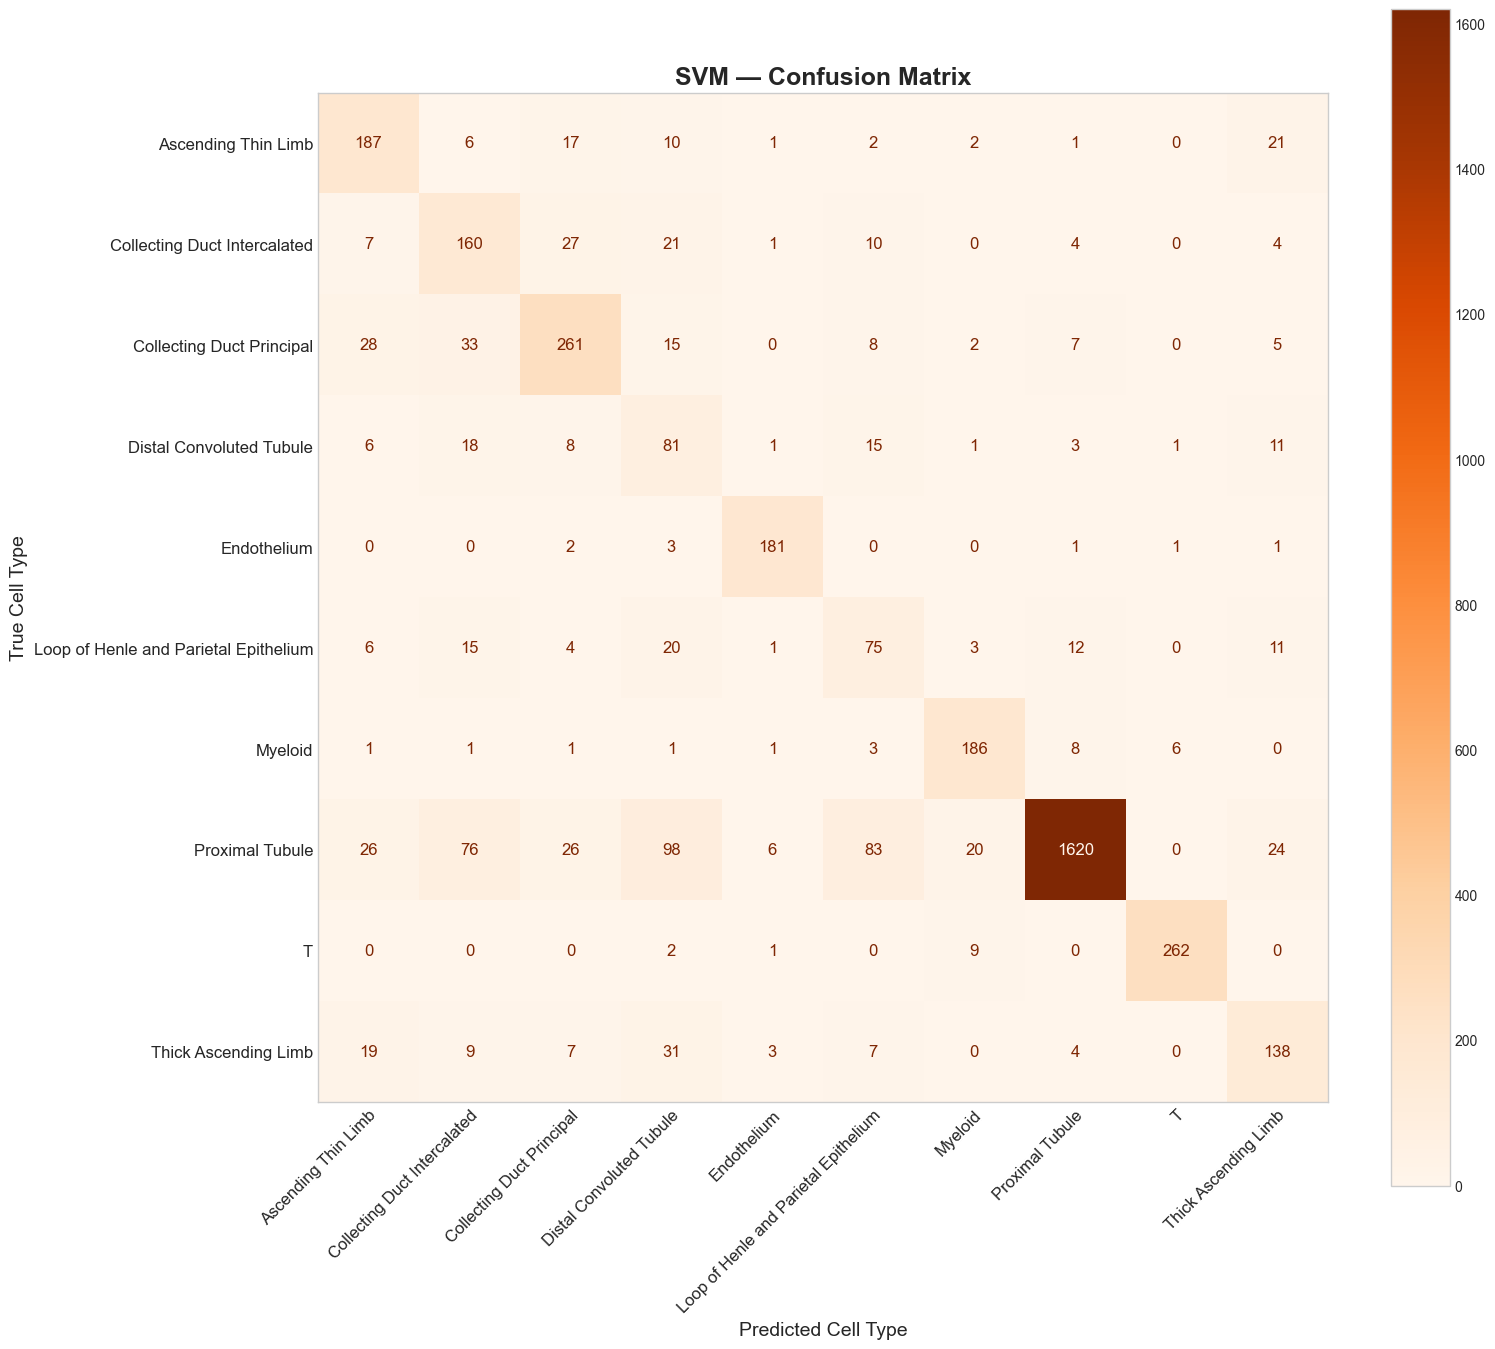

Correct predictions per class:
  Ascending Thin Limb                                    :  187 /  247  (75.7%)
  Distal Convoluted Tubule                               :   81 /  145  (55.9%)
  Endothelium                                            :  181 /  189  (95.8%)
  Loop of Henle and Parietal Epithelium                  :   75 /  147  (51.0%)
  Myeloid                                                :  186 /  208  (89.4%)
  Proximal Tubule                                        : 1620 / 1979  (81.9%)
  T                                                      :  262 /  274  (95.6%)
  Thick Ascending Limb                                   :  138 /  218  (63.3%)


In [7]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Oranges', colorbar=True, xticks_rotation=45, text_kw={'fontsize': 12})
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')  # fix label alignment for rotated text
ax.set_title('SVM — Confusion Matrix', fontsize=18, fontweight='bold')
ax.set_xlabel('Predicted Cell Type', fontsize=14)
ax.set_ylabel('True Cell Type', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False) # Remove grid lines
plt.tight_layout()
plt.show()

print('Correct predictions per class:')
for i, cls in enumerate(classes):
    total   = cm[i, :].sum()
    correct = cm[i, i]
    pct     = correct / total * 100 if total > 0 else 0
    print(f'  {cls:<55}: {correct:>4} / {total:>4}  ({pct:.1f}%)')

**Interpreting the SVM confusion matrix:** Rows are the true cell type, columns the predicted one. The bright diagonal shows most cells are classified correctly; the off-diagonal entries are confusions, which cluster among biologically related tubule subtypes.

## 9. ROC Curves (One-vs-Rest)

ROC curves for all 10 cell types, using the same one-vs-rest approach as Notebook 3. A higher curve (larger AUC) means the model is better at separating that cell type from all others in terms of its probability scores.

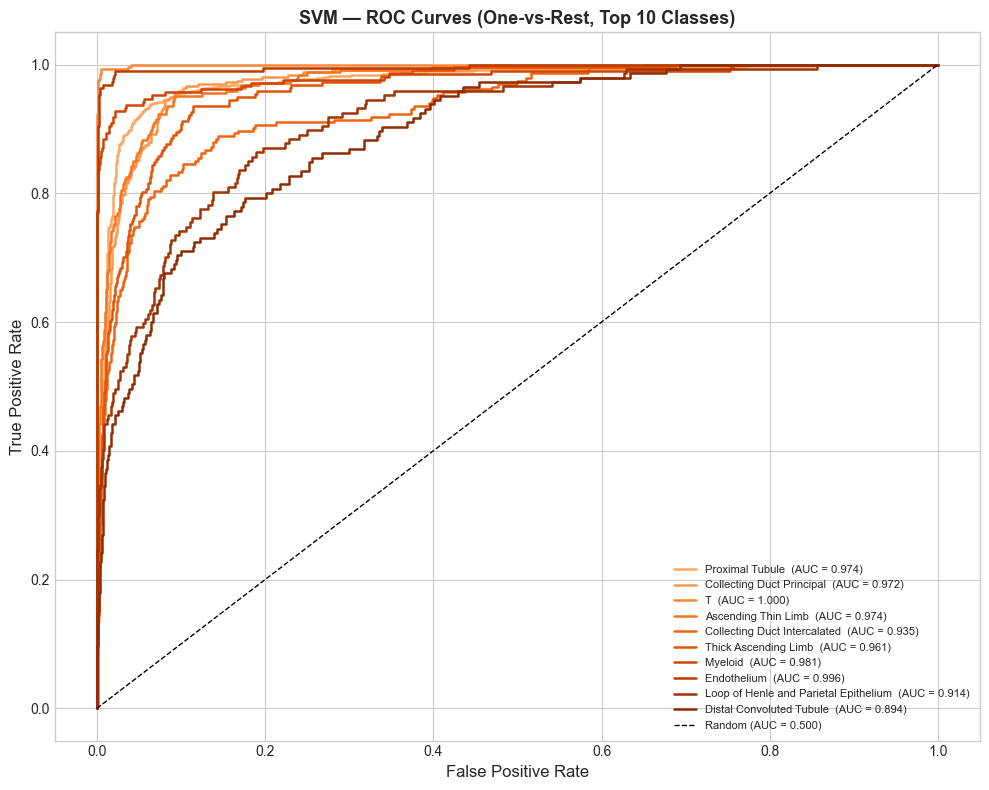

In [8]:
y_test_bin = label_binarize(y_test, classes=classes)

top_classes_idx = [
    classes.index(c)
    for c in pd.Series(y_test.values).value_counts().head(10).index.tolist()
]

fig, ax = plt.subplots(figsize=(10, 8))
colours = plt.cm.Oranges(np.linspace(0.4, 0.95, len(top_classes_idx)))

for idx, colour in zip(top_classes_idx, colours):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linewidth=1.8,
            label=f'{classes[idx]}  (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_title('SVM — ROC Curves (One-vs-Rest, Top 10 Classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Interpreting the SVM ROC Curves:**

Each curve shows one cell type in a one-vs-rest setup. A curve hugging the top-left corner is ideal. AUC = 1.0 is perfect; AUC = 0.5 is random.

**Tuned SVM overall weighted AUC = 0.8626** -- higher than the tuned KNN's 0.8483.

**Key findings:**
- **The SVM achieves higher AUC than KNN** (0.8626 vs 0.8483) even though its F1 is lower (0.5350 vs 0.5618). This is the precision-recall trade-off in action: the SVM's probability scores are better calibrated for ranking (AUC), but it makes more conservative hard predictions that miss more cells (lower recall = lower F1).
- **Proximal Tubule, Myeloid, and T cells** have the strongest individual AUC curves -- abundant classes with distinct gene signatures.
- **Ascending Thin Limb, Distal Convoluted Tubule, and Thick Ascending Limb** have the weakest curves -- their probability scores barely rise above the diagonal, reflecting how similar these tubule subtypes look in the 17-gene feature space.

**The AUC vs F1 gap:** The SVM is better at knowing *which* class is most likely (AUC), but worse at committing to a correct prediction (F1). For this biological task -- where we want to identify as many cells correctly as possible -- the higher F1 of KNN makes it the preferred model.

## 10. Per-Class Performance

Per-class F1 scores sorted from worst to best. This shows which cell types the SVM finds easy and which it still struggles with, and lets us compare directly with the KNN per-class results from Notebook 3.

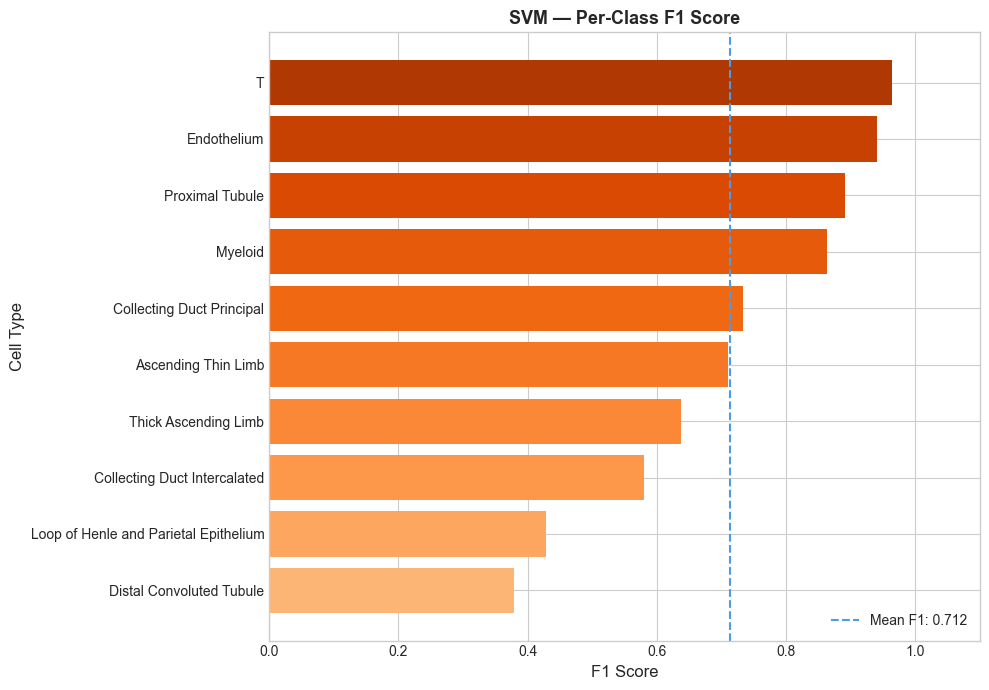

Per-class F1 scores (sorted ascending):
  Distal Convoluted Tubule                               : F1 = 0.379  (n = 145)
  Loop of Henle and Parietal Epithelium                  : F1 = 0.429  (n = 147)
  Thick Ascending Limb                                   : F1 = 0.637  (n = 218)
  Ascending Thin Limb                                    : F1 = 0.710  (n = 247)
  Myeloid                                                : F1 = 0.863  (n = 208)
  Proximal Tubule                                        : F1 = 0.890  (n = 1979)
  Endothelium                                            : F1 = 0.940  (n = 189)
  T                                                      : F1 = 0.963  (n = 274)


In [9]:
report    = classification_report(y_test, y_pred, labels=classes, target_names=classes, output_dict=True)
per_class = pd.DataFrame(report).T.loc[classes, ['precision', 'recall', 'f1-score', 'support']]
per_class = per_class.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.cm.Oranges(np.linspace(0.35, 0.85, len(per_class)))
ax.barh(per_class.index, per_class['f1-score'], color=colours)
ax.axvline(x=per_class['f1-score'].mean(), color='#4C9BE8', linestyle='--',
           linewidth=1.5, label=f'Mean F1: {per_class["f1-score"].mean():.3f}')
ax.set_title('SVM — Per-Class F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_xlim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Per-class F1 scores (sorted ascending):')
for cls in per_class.index:
    f1  = per_class.loc[cls, 'f1-score']
    sup = int(per_class.loc[cls, 'support'])
    print(f'  {cls:<55}: F1 = {f1:.3f}  (n = {sup})')

## 11. Model Comparison — KNN vs SVM

To compare both models on the same footing, re-run KNN here with the best hyperparameters from Notebook 3. Paste them into the cell below.

To compare KNN and SVM fairly, we re-run KNN here using the best hyperparameters saved by Notebook 3. Both models are trained on exactly the same `X_train` and evaluated on exactly the same `X_test`, so any difference in scores reflects a genuine difference between the two algorithms, not a difference in data or settings.

In [10]:
import json

with open(data_dir / 'knn_best_params.json') as f:
    best_knn_params = json.load(f)
print('Loaded KNN params:', best_knn_params)

# Re-run KNN with the same per-fold balancing so the comparison is apples-to-apples.
knn_compare = ImbPipeline(make_resamplers() + [
    ('knn', KNeighborsClassifier(**best_knn_params))])
knn_compare.fit(X_train, y_train)
y_pred_knn = knn_compare.predict(X_test)
y_prob_knn = knn_compare.predict_proba(X_test)

knn_f1        = f1_score(y_test, y_pred_knn, average='weighted')
knn_roc_auc   = roc_auc_score(y_test, y_prob_knn, multi_class='ovr', average='weighted')
knn_precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_recall    = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

svm_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
svm_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)

comparison_df = pd.DataFrame({
    'Weighted F1' : [knn_f1,        tuned_f1],
    'ROC-AUC'     : [knn_roc_auc,   tuned_roc_auc],
    'Precision'   : [knn_precision, svm_precision],
    'Recall'      : [knn_recall,    svm_recall],
}, index=['KNN', 'SVM']).round(4)

print()
print('Model Comparison:')
print(comparison_df.to_string())
print()
print(f'Best model by Weighted F1 : {comparison_df["Weighted F1"].idxmax()}')

Loaded KNN params: {'metric': 'manhattan', 'n_neighbors': 24, 'weights': 'distance'}



Model Comparison:
     Weighted F1  ROC-AUC  Precision  Recall
KNN       0.6338   0.9143     0.7835  0.5748
SVM       0.8036   0.9691     0.8323  0.7877

Best model by Weighted F1 : SVM


**Interpreting the comparison:** Both models were trained and evaluated on exactly the same data - same selected genes, same train/test split, same per-fold balancing - so the head-to-head is fair. Compare them on Weighted F1 (overall accuracy across classes), ROC-AUC (ranking ability), and the precision/recall trade-off.

A grouped bar chart showing Weighted F1, ROC-AUC, Precision, and Recall for KNN (blue) and SVM (orange) side by side. The number printed on top of each bar is the exact score.

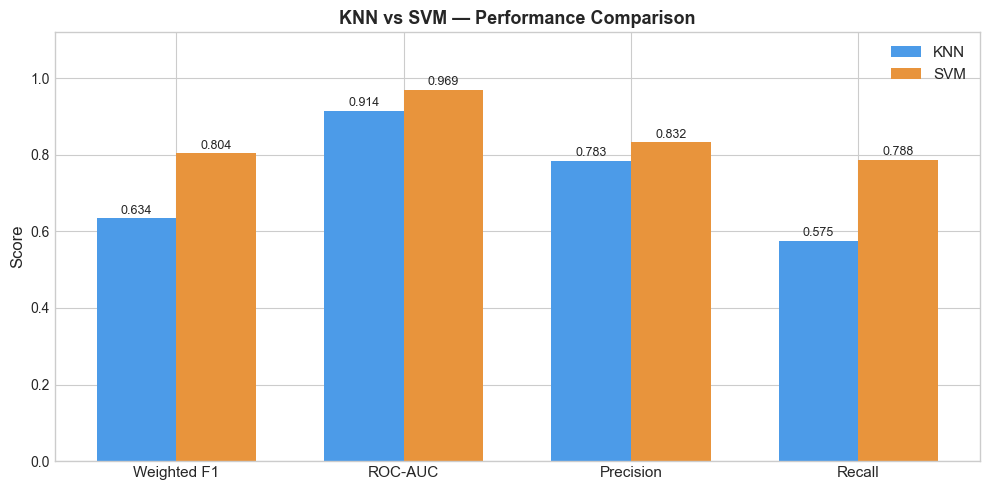

In [11]:
# Bar chart comparison
metrics    = ['Weighted F1', 'ROC-AUC', 'Precision', 'Recall']
knn_scores = comparison_df.loc['KNN'].values
svm_scores = comparison_df.loc['SVM'].values

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_knn = ax.bar(x - width/2, knn_scores, width, label='KNN', color='#4C9BE8')
bars_svm = ax.bar(x + width/2, svm_scores, width, label='SVM', color='#E8943C')

for bar in bars_knn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('KNN vs SVM — Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Both ROC curves plotted on the same axes for the largest class (Proximal Tubule). This gives a direct visual comparison of how well each model separates that class from all others across all probability thresholds.

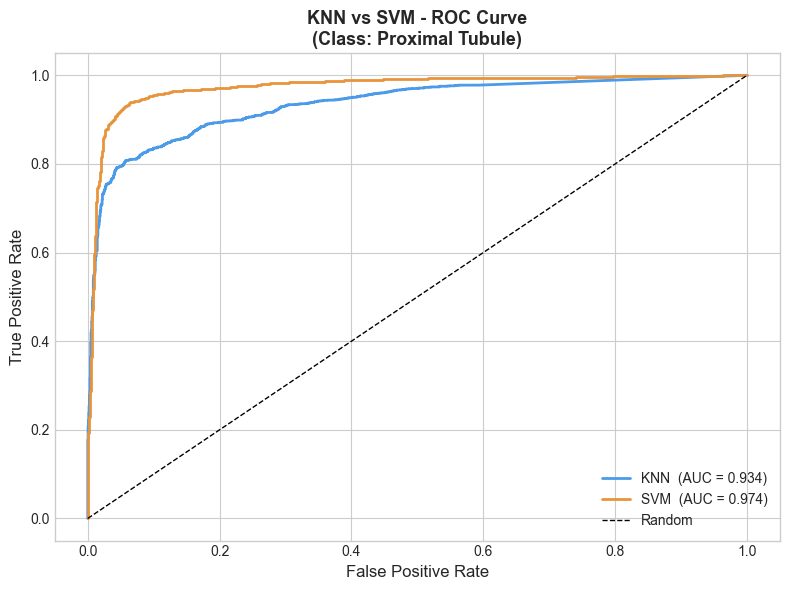

In [12]:
# Overlaid ROC curves for the largest class (Proximal Tubule)
largest_class     = pd.Series(y_test.values).value_counts().index[0]
largest_class_idx = classes.index(largest_class)

# Both pipelines expose .classes_ from their final estimator; confirm the
# predict_proba column order matches `classes` before indexing into it.
assert list(best_svm.classes_)    == classes, 'SVM class order mismatch'
assert list(knn_compare.classes_) == classes, 'KNN class order mismatch'

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, largest_class_idx], y_prob_knn[:, largest_class_idx])
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, largest_class_idx], y_prob[:, largest_class_idx])
auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_knn, tpr_knn, color='#4C9BE8', linewidth=2, label=f'KNN  (AUC = {auc_knn:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#E8943C', linewidth=2, label=f'SVM  (AUC = {auc_svm:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title(f'KNN vs SVM - ROC Curve\n(Class: {largest_class})', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 12. Summary

Final results for SVM and the head-to-head comparison with KNN. This cell prints the best SVM hyperparameters, all four evaluation metrics for both models, and declares the winner by Weighted F1.

---

## How to Improve SVM Further

The tuned SVM scores **Weighted F1 = 0.5350** and **AUC = 0.8626**. It outperforms KNN on AUC and Precision, but lags on F1 and Recall. The same four tubule subtypes that hurt KNN (Distal Convoluted Tubule F1=0.17, Loop of Henle F1=0.18, Ascending Thin Limb F1=0.16, Thick Ascending Limb F1=0.24) remain the primary weakness. Here are concrete ways to improve:

**1. Increase the number of selected features**
Re-run Notebook 2 with more genes (e.g. 30, 50, or 100). SVM with an RBF kernel can exploit a richer feature space effectively -- more genes means more dimensions for the kernel to find non-linear boundaries between the overlapping tubule subtypes.

**2. Apply SMOTE**
Enable the SMOTE block in Notebook 2. The current training set is imbalanced (Proximal Tubule ~49%), which causes the SVM's `class_weight='balanced'` to over-correct for some minority classes (notably Endothelium). SMOTE provides a more natural balance and may reduce the over-prediction problem.

**3. Increase Bayesian search trials**
Increase `n_iter` from 20 to 50 or more. The current best (C=2.94, gamma=0.126) was found from only 20 trials -- more trials give the Bayesian optimiser more time to converge on a better region of the search space.

**4. Try a linear kernel with a wider C range**
With only 17 features, a linear kernel may outperform RBF. Expand the search to include `C` values up to 1,000 on a log scale and force `kernel='linear'` to test this directly.

**5. Use all 20,000 cells**
This run used a 10,000-cell sample. Doubling to 20,000 gives the SVM more support vectors for rare classes, which improves its ability to define tight margins around small populations like Distal Convoluted Tubule.

In [13]:
winner = comparison_df['Weighted F1'].idxmax()

print('NOTEBOOK 4 - SVM - FINAL RESULTS')
print()
print('Best SVM hyperparameters:')
for param, value in best_params.items():
    print(f'  {param:<8}: {value}')
print()
print(f'Baseline Weighted F1  : {base_f1:.4f}')
print(f'Tuned    Weighted F1  : {tuned_f1:.4f}')
print(f'Baseline ROC-AUC      : {base_roc_auc:.4f}')
print(f'Tuned    ROC-AUC      : {tuned_roc_auc:.4f}')
print()
print('Final model comparison:')
print()
print(comparison_df.to_string())
print()
print(f'Best model by Weighted F1 : {winner}')
print()
print('Pipeline complete.')

NOTEBOOK 4 - SVM - FINAL RESULTS

Best SVM hyperparameters:
  C       : 17.76576664980768
  gamma   : 0.00032780432870046914

Baseline Weighted F1  : 0.7890
Tuned    Weighted F1  : 0.8036
Baseline ROC-AUC      : 0.9711
Tuned    ROC-AUC      : 0.9691

Final model comparison:

     Weighted F1  ROC-AUC  Precision  Recall
KNN       0.6338   0.9143     0.7835  0.5748
SVM       0.8036   0.9691     0.8323  0.7877

Best model by Weighted F1 : SVM

Pipeline complete.
